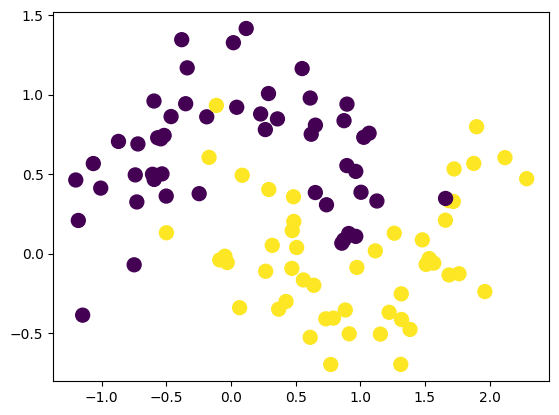

In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

#nosie=표준편차
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=100)

In [3]:
from sklearn.model_selection import train_test_split
# test_size없으면 7.5:2.5
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

In [4]:
#의사결정나무
from sklearn.tree import DecisionTreeClassifier
    # max_depth : 몇단계까지 진행할것인지  #creteion 혼잡도 계산기준 = entropy / gini
model = DecisionTreeClassifier(random_state=2, max_depth=3, criterion='entropy')
model.fit(X_train, y_train)
print('학습용:',model.score(X_train, y_train))
print('검증용:',model.score(X_test, y_test))

학습용: 0.9066666666666666
검증용: 0.92


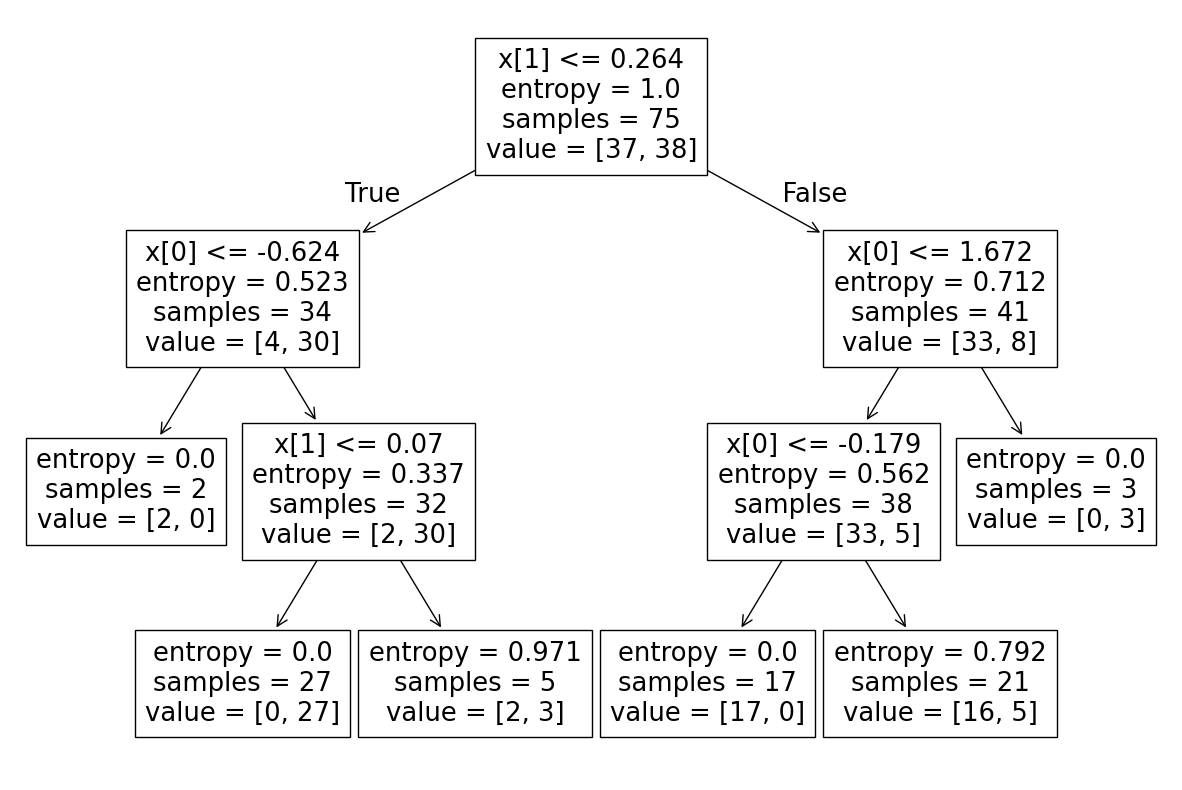

In [5]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(model)
plt.show()

In [ ]:
# entropy : 혼잡도 0~1
# samples = 샘플개수
# value = [0이 몇개, 1이 몇개]

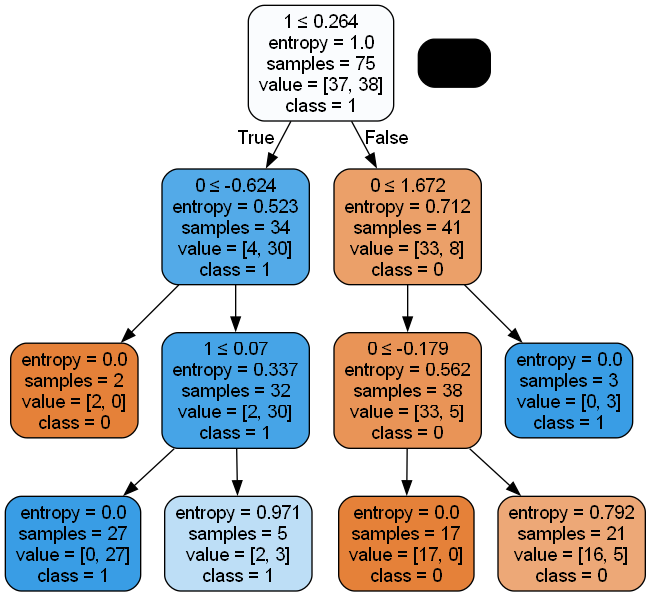

In [6]:
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image
dot_data = export_graphviz(model, out_file=None, feature_names=['0','1'], class_names=['0','1'], filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

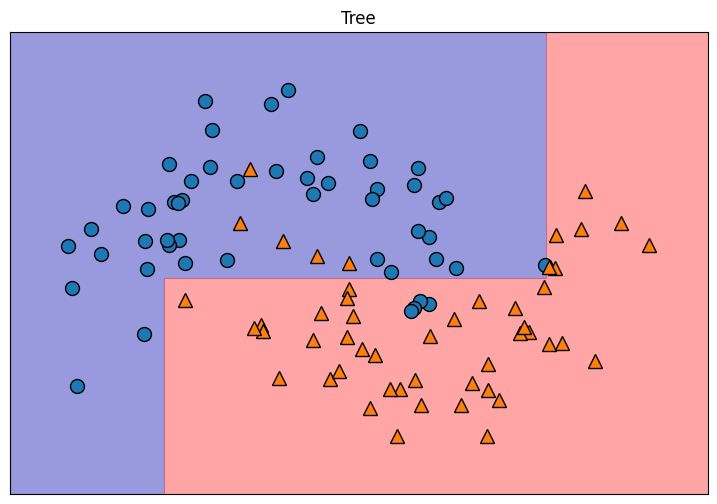

In [8]:
import matplotlib.pyplot as plt
import mglearn
plt.figure(figsize=(9,6))
plt.title('Tree')
#클래스 구분면
mglearn.plots.plot_2d_separator(model, X, fill=True, alpha=0.4)
#산점도
mglearn.discrete_scatter(X[:,0], X[:,1], y)
plt.show()